## Task 1: Data Acquisition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("train.csv")
print("Dataset dimensions:", df.shape)

Dataset dimensions: (891, 12)


In [2]:
print("Column names:")
print(list(df.columns))

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

## Task 2: Data Cleaning

In [5]:
# Detect missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# Detect duplicated rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()

# Age -> impute with the median Age within each Pclass/Sex group.
# This is more accurate than a single global median because age varies
# systematically with class and sex in this dataset.
df_clean["Age"] = df_clean.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

# Embarked -> only 2 missing values, filled with the mode (most frequent port).
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# Cabin -> ~77% missing, too sparse to impute reliably.
# We extract a binary HasCabin flag (whether cabin was recorded) and drop the raw column.
df_clean["HasCabin"] = df_clean["Cabin"].notna().astype(int)
df_clean = df_clean.drop(columns=["Cabin"])

print("Missing values after cleaning:")
print(df_clean.isnull().sum())
print("\nShape after cleaning:", df_clean.shape)

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64

Shape after cleaning: (891, 12)


**Preprocessing decisions:**
- `Age` (177 missing): imputed using the median age of passengers sharing the same
  `Pclass` and `Sex`, since age differs systematically across these groups (e.g. 1st class
  passengers were on average older). This is more representative than a single global median.
- `Embarked` (2 missing): imputed with the mode (`S`, Southampton), since only two rows were
  affected and dropping them would lose negligible information.
- `Cabin` (687 missing, ~77%): too sparse for reliable imputation. A binary indicator
  `HasCabin` was engineered instead (cabin recorded vs not), which retains predictive signal
  related to socio-economic status, and the raw column was dropped.
- `PassengerId`, `Name`, `Ticket` are identifiers with no cleaning required; they are excluded
  from statistical/ML analysis as they carry no direct predictive value in raw form.
- No duplicate rows were found in the dataset.

## Task 3: Data Visualisation

### 3.1 Histogram of Passenger Ages

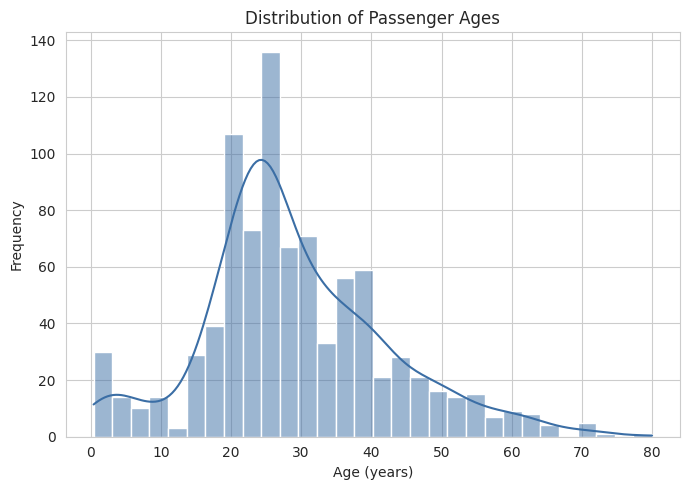

In [8]:
plt.figure(figsize=(7, 5))
sns.histplot(df_clean["Age"], bins=30, kde=True, color="#3b6ea5")
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age (years)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation:** Ages are concentrated between roughly 20 and 40 years, with a peak around
the mid-20s. There is a smaller secondary bump for infants/young children, and a long right
tail of older passengers up to age 80.

### 3.2 Bar Chart: Passenger Class Distribution

/tmp/ipykernel_608/3604580525.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Pclass", data=df_clean, order=[1, 2, 3], palette="viridis")


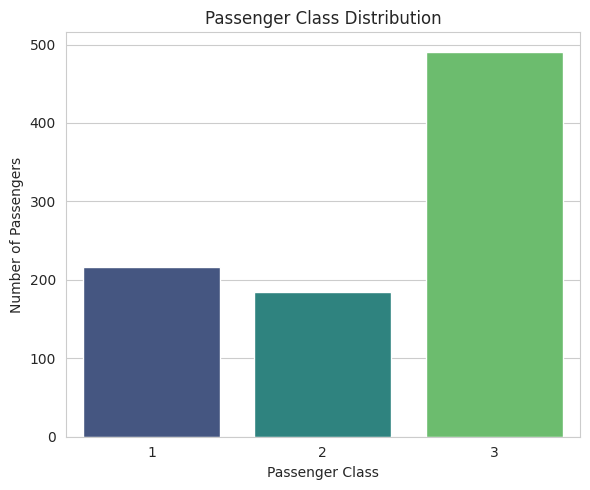

In [9]:
plt.figure(figsize=(6, 5))
sns.countplot(x="Pclass", data=df_clean, order=[1, 2, 3], palette="viridis")
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

**Interpretation:** Third class passengers make up the largest group (491), followed by
first class (216) and second class (184). More than half of all passengers travelled in
third class.

### 3.3 Boxplot: Age by Passenger Class

/tmp/ipykernel_608/749411959.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pclass", y="Age", data=df_clean, palette="Set2")


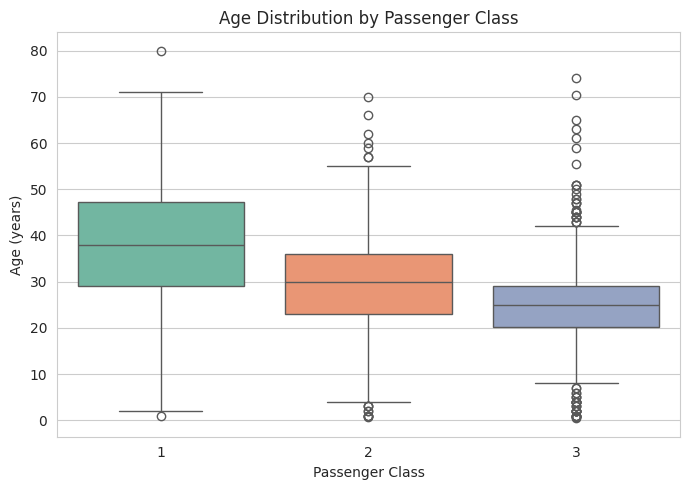

In [10]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="Pclass", y="Age", data=df_clean, palette="Set2")
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.show()

**Interpretation:** Median age decreases as class number increases — first class passengers
were, on average, oldest, and third class passengers were youngest. First class also shows a
wider spread and more high-age outliers.

### 3.4 Scatter Plot: Age vs Fare

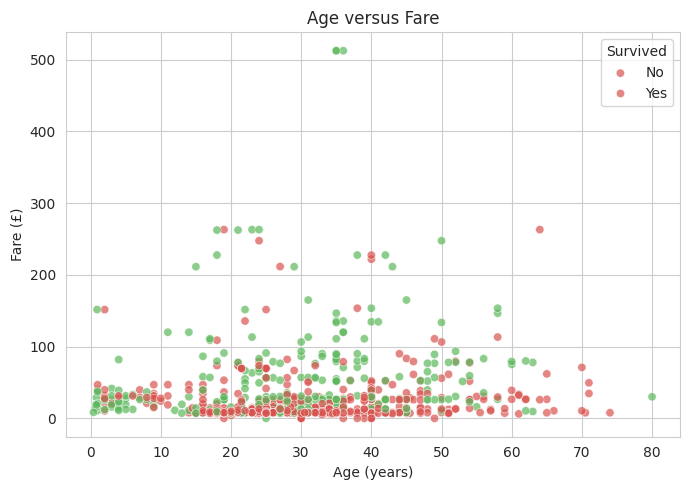

In [11]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df_clean,
                 palette=["#d9534f", "#5cb85c"], alpha=0.7)
plt.title("Age versus Fare")
plt.xlabel("Age (years)")
plt.ylabel("Fare (£)")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

**Interpretation:** Most passengers paid modest fares regardless of age, but a handful of
high-fare outliers (mostly first class) appear across most ages. Survivors (green) are
noticeably more frequent among higher-fare passengers.

### 3.5 Correlation Heatmap

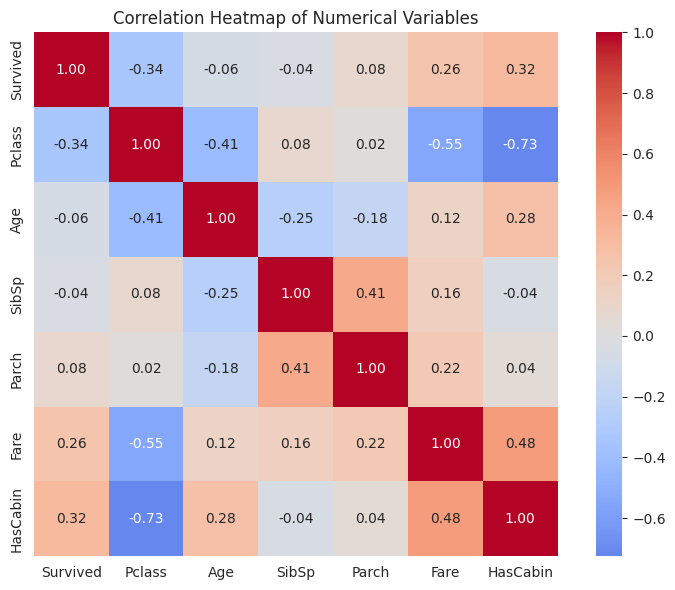

In [12]:
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "HasCabin"]
corr = df_clean[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

**Interpretation:** `Pclass` correlates negatively with `Survived` (-0.34) and `Fare`
(-0.55) — lower class number (better class) is associated with higher survival and higher
fare. `HasCabin` correlates strongly with `Pclass` (-0.73) and `Fare` (0.48), since cabin
numbers were mostly recorded for higher-class tickets.

### 3.6 Pairplot of Selected Numerical Variables

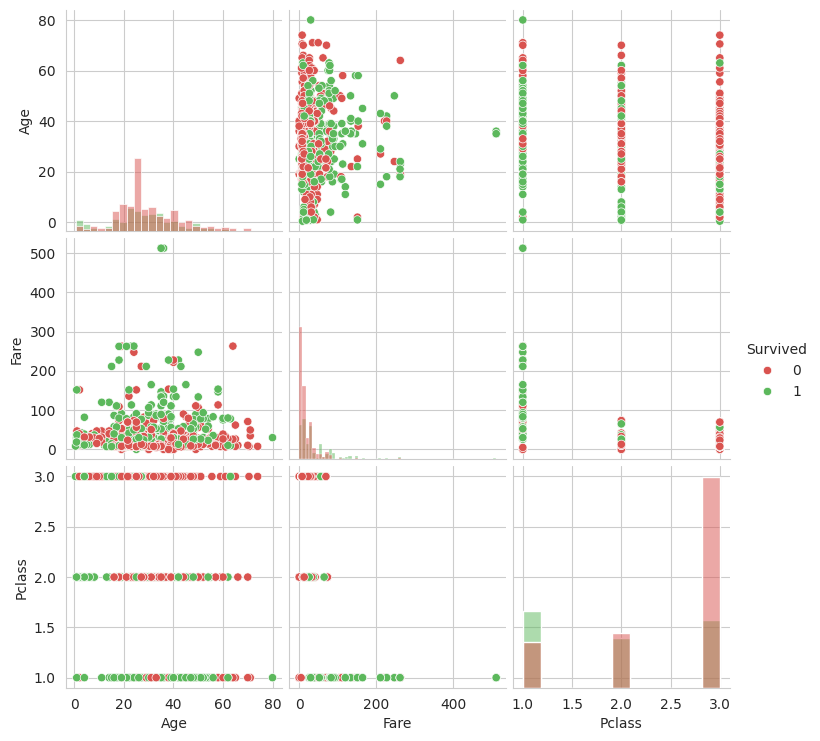

In [13]:
pair_cols = ["Age", "Fare", "Pclass", "Survived"]
sns.pairplot(df_clean[pair_cols], hue="Survived", palette=["#d9534f", "#5cb85c"], diag_kind="hist")
plt.show()

**Interpretation:** The pairplot confirms the fare/class relationship (lower Pclass numbers
cluster with higher fares) and shows survivors (green) skew toward higher fares and lower
(i.e., better) passenger classes, while age alone shows weaker separation between the two
survival groups.

## Task 4: Statistical Analysis

### 4.1 Descriptive Statistics

In [14]:
df_clean[["Age", "Fare", "SibSp", "Parch", "Pclass"]].describe()

,Age,Fare,SibSp,Parch,Pclass
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,29.112424,32.204208,0.523008,0.381594,2.308642
std,13.304424,49.693429,1.102743,0.806057,0.836071
min,0.420000,0.000000,0.000000,0.000000,1.000000
25%,21.500000,7.910400,0.000000,0.000000,2.000000
50%,26.000000,14.454200,0.000000,0.000000,3.000000
75%,36.000000,31.000000,1.000000,0.000000,3.000000
max,80.000000,512.329200,8.000000,6.000000,3.000000


### 4.2 Frequency Distributions

In [15]:
print("Survived:\n", df_clean["Survived"].value_counts(), "\n")
print("Pclass:\n", df_clean["Pclass"].value_counts(), "\n")
print("Sex:\n", df_clean["Sex"].value_counts(), "\n")
print("Embarked:\n", df_clean["Embarked"].value_counts())

Survived:
 Survived
0    549
1    342
Name: count, dtype: int64 

Pclass:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64 

Sex:
 Sex
male      577
female    314
Name: count, dtype: int64 

Embarked:
 Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


### 4.3 Correlation Analysis

In [16]:
corr.round(2)

,Survived,Pclass,Age,SibSp,Parch,Fare,HasCabin
Survived,1.00,-0.34,-0.06,-0.04,0.08,0.26,0.32
Pclass,-0.34,1.00,-0.41,0.08,0.02,-0.55,-0.73
Age,-0.06,-0.41,1.00,-0.25,-0.18,0.12,0.28
SibSp,-0.04,0.08,-0.25,1.00,0.41,0.16,-0.04
Parch,0.08,0.02,-0.18,0.41,1.00,0.22,0.04
Fare,0.26,-0.55,0.12,0.16,0.22,1.00,0.48
HasCabin,0.32,-0.73,0.28,-0.04,0.04,0.48,1.00


**Strongest positive correlation (excluding the engineered `HasCabin` flag):**
`Parch` and `SibSp` (0.41) — passengers travelling with siblings/spouses also tended to
travel with parents/children (family groups).

**Strongest negative correlation:** `Pclass` and `Fare` (-0.55) — as passenger class number
increases (i.e. class gets lower/worse), fare paid decreases sharply.

(Note: `HasCabin` correlates even more strongly with `Pclass`, -0.73, but this is an
engineered variable directly derived from ticket/cabin records rather than an independent
passenger attribute.)

### 4.4 Three Important Statistical Findings

1. **Sex was the strongest single predictor of survival.** 74.2% of female passengers
   survived compared to only 18.9% of male passengers — consistent with the "women and
   children first" evacuation protocol.
2. **Survival rate declined steadily with passenger class.** First class: 63.0% survived;
   second class: 47.3%; third class: 24.2%. Wealthier passengers had significantly better
   access to lifeboats.
3. **Fare and class jointly reflect socio-economic stratification.** `Fare` is negatively
   correlated with `Pclass` (-0.55) and positively correlated with `Survived` (0.26),
   suggesting that ticket price acted as a proxy for both social status and survival
   likelihood.

In [17]:
print("Survival rate by sex:")
print(df_clean.groupby("Sex")["Survived"].mean())
print("\nSurvival rate by class:")
print(df_clean.groupby("Pclass")["Survived"].mean())

Survival rate by sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


## Task 5: Machine Learning — Predicting Survival

In [18]:
ml_df = df_clean.copy()
le_sex = LabelEncoder()
ml_df["Sex_enc"] = le_sex.fit_transform(ml_df["Sex"])
le_emb = LabelEncoder()
ml_df["Embarked_enc"] = le_emb.fit_transform(ml_df["Embarked"])

features = ["Pclass", "Sex_enc", "Age", "SibSp", "Parch", "Fare", "Embarked_enc"]
X = ml_df[features]
y = ml_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 712
Testing set size: 179


In [19]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [20]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Did Not Survive", "Survived"]))

Accuracy: 0.8212

Confusion Matrix:
 [[99 11]
 [21 48]]

Classification Report:

                 precision    recall  f1-score   support

Did Not Survive       0.82      0.90      0.86       110
       Survived       0.81      0.70      0.75        69

       accuracy                           0.82       179
      macro avg       0.82      0.80      0.81       179
   weighted avg       0.82      0.82      0.82       179



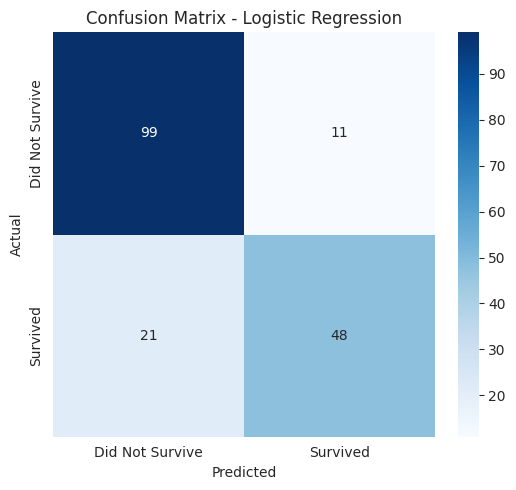

In [21]:
plt.figure(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Did Not Survive", "Survived"],
            yticklabels=["Did Not Survive", "Survived"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

**Model performance discussion:** The Logistic Regression model achieved **82.1% accuracy**
on the held-out test set (179 passengers). It correctly identified 99 of 110 non-survivors
and 48 of 69 survivors. Precision and recall are higher for the "Did Not Survive" class
(0.82 / 0.90) than for "Survived" (0.81 / 0.70), meaning the model is somewhat more
conservative about predicting survival, missing some true survivors (21 false negatives)
while rarely misclassifying non-survivors as survivors (11 false positives). The
coefficients show `Sex` and `Pclass` as the strongest predictors, consistent with the
statistical findings above.

## Task 6: Discussion and Conclusion

See the accompanying project report (PDF/Word document) for the full discussion of major
findings, statistical insights, machine learning results, limitations, and recommendations.